```
数据集来源于和鲸社区
```

```
背景描述
此数据集包含电子商务平台的50万条客户购买行为记录。
数据说明
Age（整数）：客户的年龄（以年为单位）。范围：15-81岁。
AnnualIncome（浮点数）：客户的年收入（以美元为单位）。范围：11,966-204,178美元。
NumberOfPurchases（整数）：客户的总购买次数。可用于表示参与度。
TimeSpentOnWebsite（浮点数）：每次访问网站的平均停留时间（以分钟为单位）。
CustomerTenureYears（浮点数）：客户加入平台的时长（以年为单位）。
LastPurchaseDaysAgo（整数）：距离客户最近一次购买的天数。
Gender（分类变量：Male/Female）：客户的性别。
ProductCategory（分类变量：Fashion、Electronics、Furniture、Groceries、Sports等）：客户最常购买的产品类别。
PreferredDevice（分类变量：Mobile/Desktop/Tablet）：客户最常使用的设备。
Region（分类变量：North、South、East、West）：客户所在的地理区域。
ReferralSource（分类变量：Organic、Paid Ads、Referral、Social Media、Email）：客户发现该平台的途径。
CustomerSegment（分类变量：Regular、Premium、VIP）：企业定义的客户分类。
LoyaltyProgram（二元变量：0/1）：客户是否加入忠诚度计划。
DiscountsAvailed（整数）：客户使用的折扣券/优惠券数量。
SessionCount（整数）：记录的客户会话/访问次数。
CustomerSatisfaction（整数：1-5）：客户满意度评分（1=非常不满意，5=非常满意）。
PurchaseStatus（目标变量，二元变量：0/1）：购买是否成功。
数据来源
https://www.kaggle.com/datasets/gauthamvijayaraj/customer-purchase-behavior-dataset-e-commerce/data
```

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示

In [3]:
data = pd.read_csv('customerData.csv')

### 数据概览

In [4]:
name_mapping = {
    "Age": "年龄",
    "AnnualIncome": "年收入(美元)",
    "NumberOfPurchases": "总购买次数",
    "TimeSpentOnWebsite": "网站平均停留时间(分钟)",
    "CustomerTenureYears": "客户注册时长(年)",
    "LastPurchaseDaysAgo": "最近一次购买天数",
    "Gender": "性别",
    "ProductCategory": "最常购买产品类别",
    "PreferredDevice": "常用设备",
    "Region": "所在地区",
    "ReferralSource": "客户来源渠道",
    "CustomerSegment": "客户分类",
    "LoyaltyProgram": "是否加入忠诚度计划",
    "DiscountsAvailed": "使用折扣券数量",
    "SessionCount": "访问会话次数",
    "CustomerSatisfaction": "客户满意度评分",
    "PurchaseStatus": "购买是否成功"
}
df = data.rename(columns=name_mapping)

In [21]:
df.head()

,年龄,年收入(美元),总购买次数,网站平均停留时间(分钟),客户注册时长(年),最近一次购买天数,性别,最常购买产品类别,常用设备,所在地区,客户来源渠道,客户分类,是否加入忠诚度计划,使用折扣券数量,访问会话次数,客户满意度评分,购买是否成功
0,37,57722.572411,19,5.908826,1.093430,11,Male,Furniture,Desktop,South,Paid Ads,Regular,1,5,3,2,1
1,63,21328.925876,10,6.970749,0.649246,20,Female,Furniture,Mobile,East,Organic,VIP,0,4,2,3,0
2,60,150537.742465,19,35.004954,3.858211,25,Male,Electronics,Desktop,South,Organic,VIP,1,2,5,2,0
3,19,63508.762549,10,14.818000,7.554374,20,Male,Furniture,Desktop,West,Paid Ads,Premium,0,0,1,3,0
4,54,100399.558368,19,55.925462,0.197411,92,Male,Electronics,Mobile,South,Referral,Regular,1,4,1,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   年龄            500000 non-null  int64  
 1   年收入(美元)       500000 non-null  float64
 2   总购买次数         500000 non-null  int64  
 3   网站平均停留时间(分钟)  500000 non-null  float64
 4   客户注册时长(年)     500000 non-null  float64
 5   最近一次购买天数      500000 non-null  int64  
 6   性别            500000 non-null  object 
 7   最常购买产品类别      500000 non-null  object 
 8   常用设备          500000 non-null  object 
 9   所在地区          500000 non-null  object 
 10  客户来源渠道        500000 non-null  object 
 11  客户分类          500000 non-null  object 
 12  是否加入忠诚度计划     500000 non-null  int64  
 13  使用折扣券数量       500000 non-null  int64  
 14  访问会话次数        500000 non-null  int64  
 15  客户满意度评分       500000 non-null  int64  
 16  购买是否成功        500000 non-null  int64  
dtypes: float64(3), int64(8), object(6)
memory usage:

In [6]:
df.describe()

,年龄,年收入(美元),总购买次数,网站平均停留时间(分钟),客户注册时长(年),最近一次购买天数,是否加入忠诚度计划,使用折扣券数量,访问会话次数,客户满意度评分,购买是否成功
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,43.941044,85071.804966,11.387584,30.594395,2.163483,60.191362,0.501110,3.154496,2.351750,3.219764,0.418354
std,15.756232,39586.271859,6.000702,17.585290,2.197354,54.886826,0.499999,1.879333,1.485597,0.826482,0.493289
min,15.000000,11966.385655,-1.000000,-3.804161,-0.418429,-11.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,30.000000,51998.815726,6.000000,15.843041,0.592285,16.000000,0.000000,2.000000,1.000000,3.000000,0.000000
50%,44.000000,83748.351846,12.000000,30.763164,1.466097,31.000000,1.000000,3.000000,2.000000,3.000000,0.000000
75%,57.000000,116554.694607,16.000000,45.012866,3.009516,105.000000,1.000000,5.000000,3.000000,4.000000,1.000000
max,81.000000,204178.294436,28.000000,78.364251,15.346356,189.000000,1.000000,10.000000,12.000000,5.000000,1.000000


### 数据预处理

In [7]:
# 变量分类 
# 连续型数值变量
continuous_cols = [
    '年龄', '年收入(美元)', '总购买次数', '网站平均停留时间(分钟)',
    '客户注册时长(年)', '最近一次购买天数', '访问会话次数'
]
# 离散型数值变量
discrete_numeric_cols = [
    '是否加入忠诚度计划', '使用折扣券数量', '客户满意度评分', '购买是否成功'
]
# 分类型变量
category_cols = [
    '性别', '最常购买产品类别', '常用设备', '所在地区', '客户来源渠道', '客户分类'
]
# 合并所有数值变量
numeric_cols = continuous_cols + discrete_numeric_cols

In [8]:
#处理异常值
cols = [
    '总购买次数',
    '网站平均停留时间(分钟)',
    '客户注册时长(年)',
    '最近一次购买天数'
]
# 转数字
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# 处理负数异常
for col in cols:
    df.loc[df[col] < 0, col] = df[col].median()

#处理无穷大或无穷小值
print("无穷大值数量：")
print(np.isinf(df[numeric_cols]).sum())

# 处理重复值
print("重复值数量")
df.duplicated().sum()

无穷大值数量：
年龄              0
年收入(美元)         0
总购买次数           0
网站平均停留时间(分钟)    0
客户注册时长(年)       0
最近一次购买天数        0
访问会话次数          0
是否加入忠诚度计划       0
使用折扣券数量         0
客户满意度评分         0
购买是否成功          0
dtype: int64
缺失值数量


0

In [9]:
df.describe()

,年龄,年收入(美元),总购买次数,网站平均停留时间(分钟),客户注册时长(年),最近一次购买天数,是否加入忠诚度计划,使用折扣券数量,访问会话次数,客户满意度评分,购买是否成功
count,500000.000000,500000.000000,500000.000000,500000.000000,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,43.941044,85071.804966,11.397828,31.127028,2.197795e+00,60.717342,0.501110,3.154496,2.351750,3.219764,0.418354
std,15.756232,39586.271859,5.990633,17.099432,2.174035e+00,54.443108,0.499999,1.879333,1.485597,0.826482,0.493289
min,15.000000,11966.385655,0.000000,0.000041,5.791866e-08,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,30.000000,51998.815726,6.000000,16.908534,6.568507e-01,17.000000,0.000000,2.000000,1.000000,3.000000,0.000000
50%,44.000000,83748.351846,12.000000,30.763164,1.466099e+00,31.000000,1.000000,3.000000,2.000000,3.000000,0.000000
75%,57.000000,116554.694607,16.000000,45.012866,3.009516e+00,105.000000,1.000000,5.000000,3.000000,4.000000,1.000000
max,81.000000,204178.294436,28.000000,78.364251,1.534636e+01,189.000000,1.000000,10.000000,12.000000,5.000000,1.000000


### 可视化分析

#### 总体分析

In [10]:
sns.set_style("whitegrid")
sns.set_palette("tab10")
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False

In [11]:
plt.rcParams['figure.dpi'] = 100  # 提升清晰度

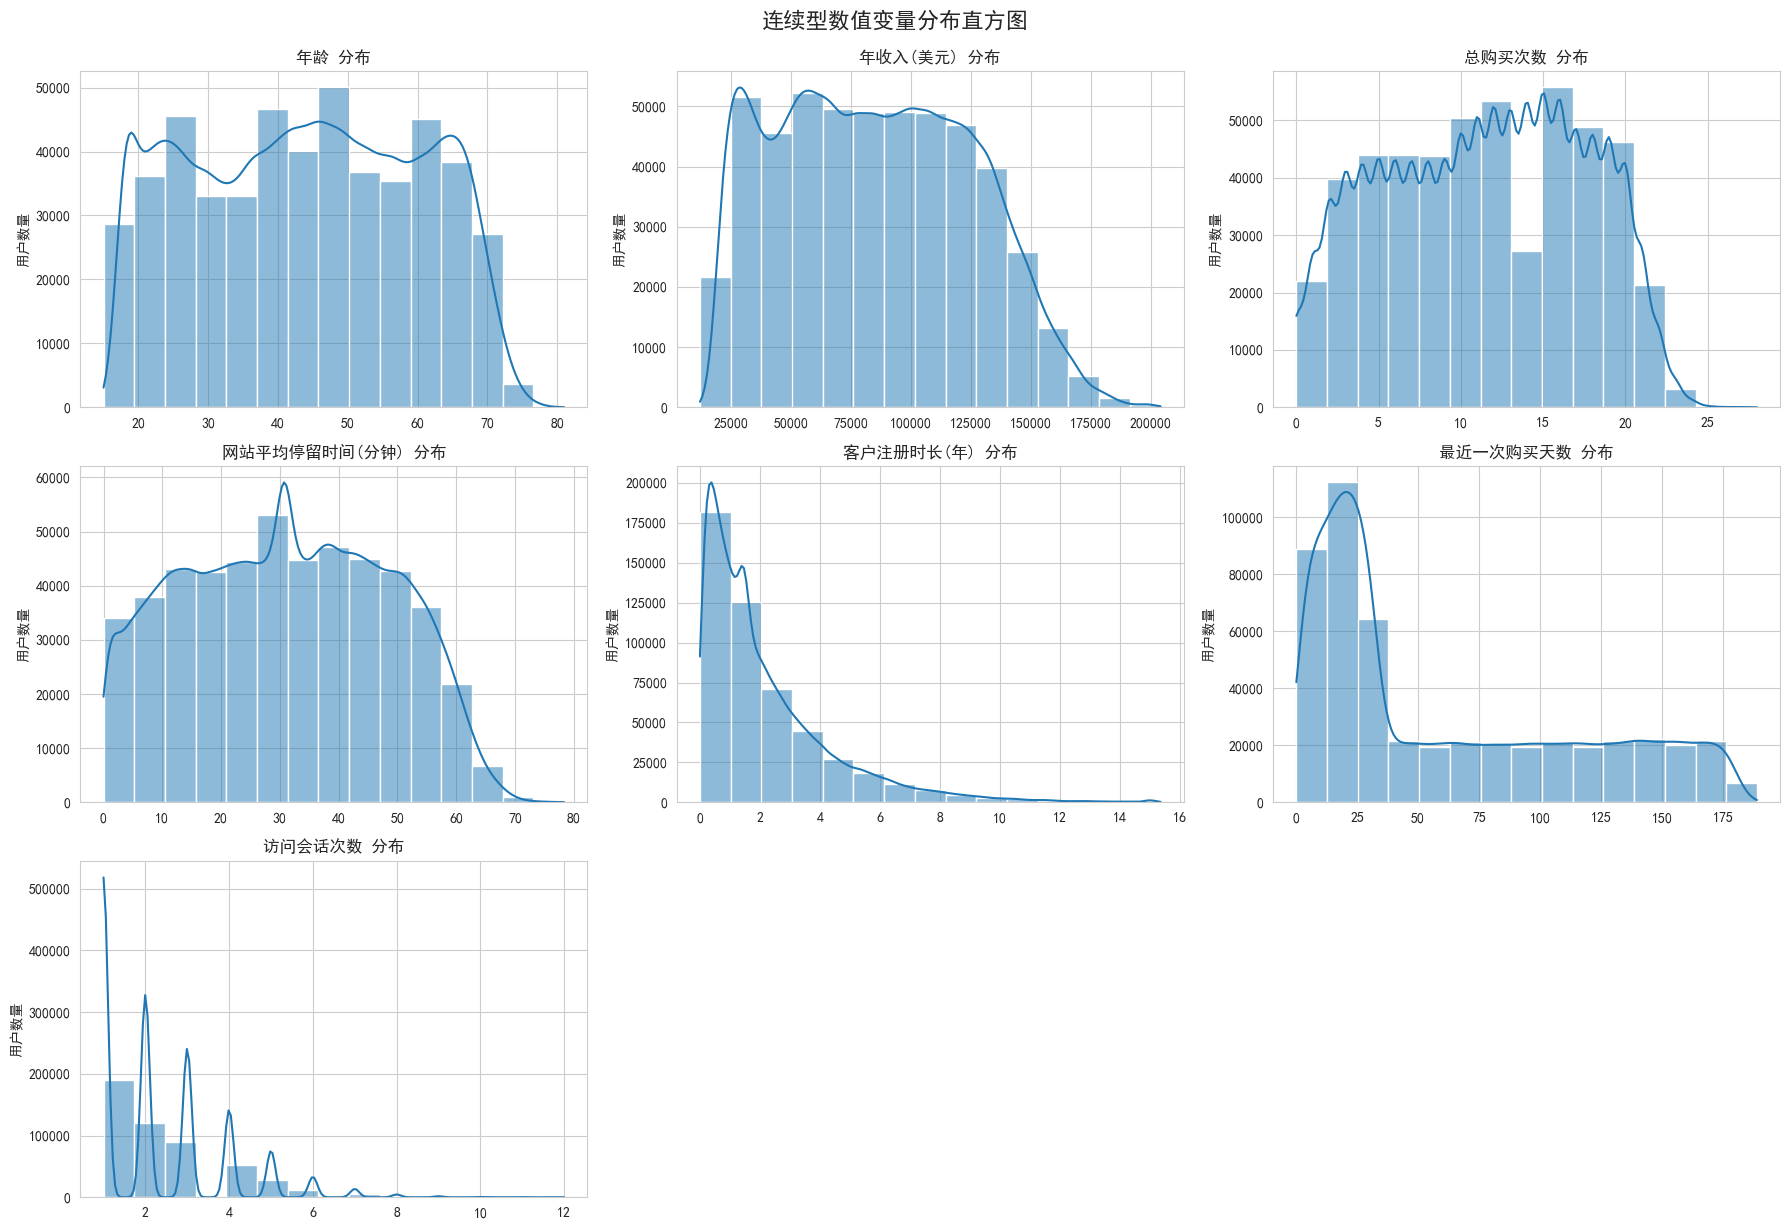

In [12]:
# 1. 连续型变量：直方图+KDE 
n_cont = len(continuous_cols)
rows_cont = (n_cont + 2) // 3
fig, axs = plt.subplots(rows_cont, 3, figsize=(18, 4 * rows_cont))
axs = axs.flatten()

for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], bins=15, kde=True, ax=axs[i])
    axs[i].set_title(f'{col} 分布', fontsize=12)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('用户数量')

# 隐藏多余子图
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle('连续型数值变量分布直方图', fontsize=16, y=1.02)
plt.show()

```
年龄与经济：以中老年、中低收入用户为主；
总购买次数：用户复购率健康；
网站停留时间：网站内容吸引力强，高停留时长用户转化潜力高；
用户注册时长：新用户占比极高，老用户留存率随时间下降明显；
最近一次购买天数：活跃用户集中在近期购买，大量用户为沉睡用户；
访问会话次数：多数用户访问频次低；
```

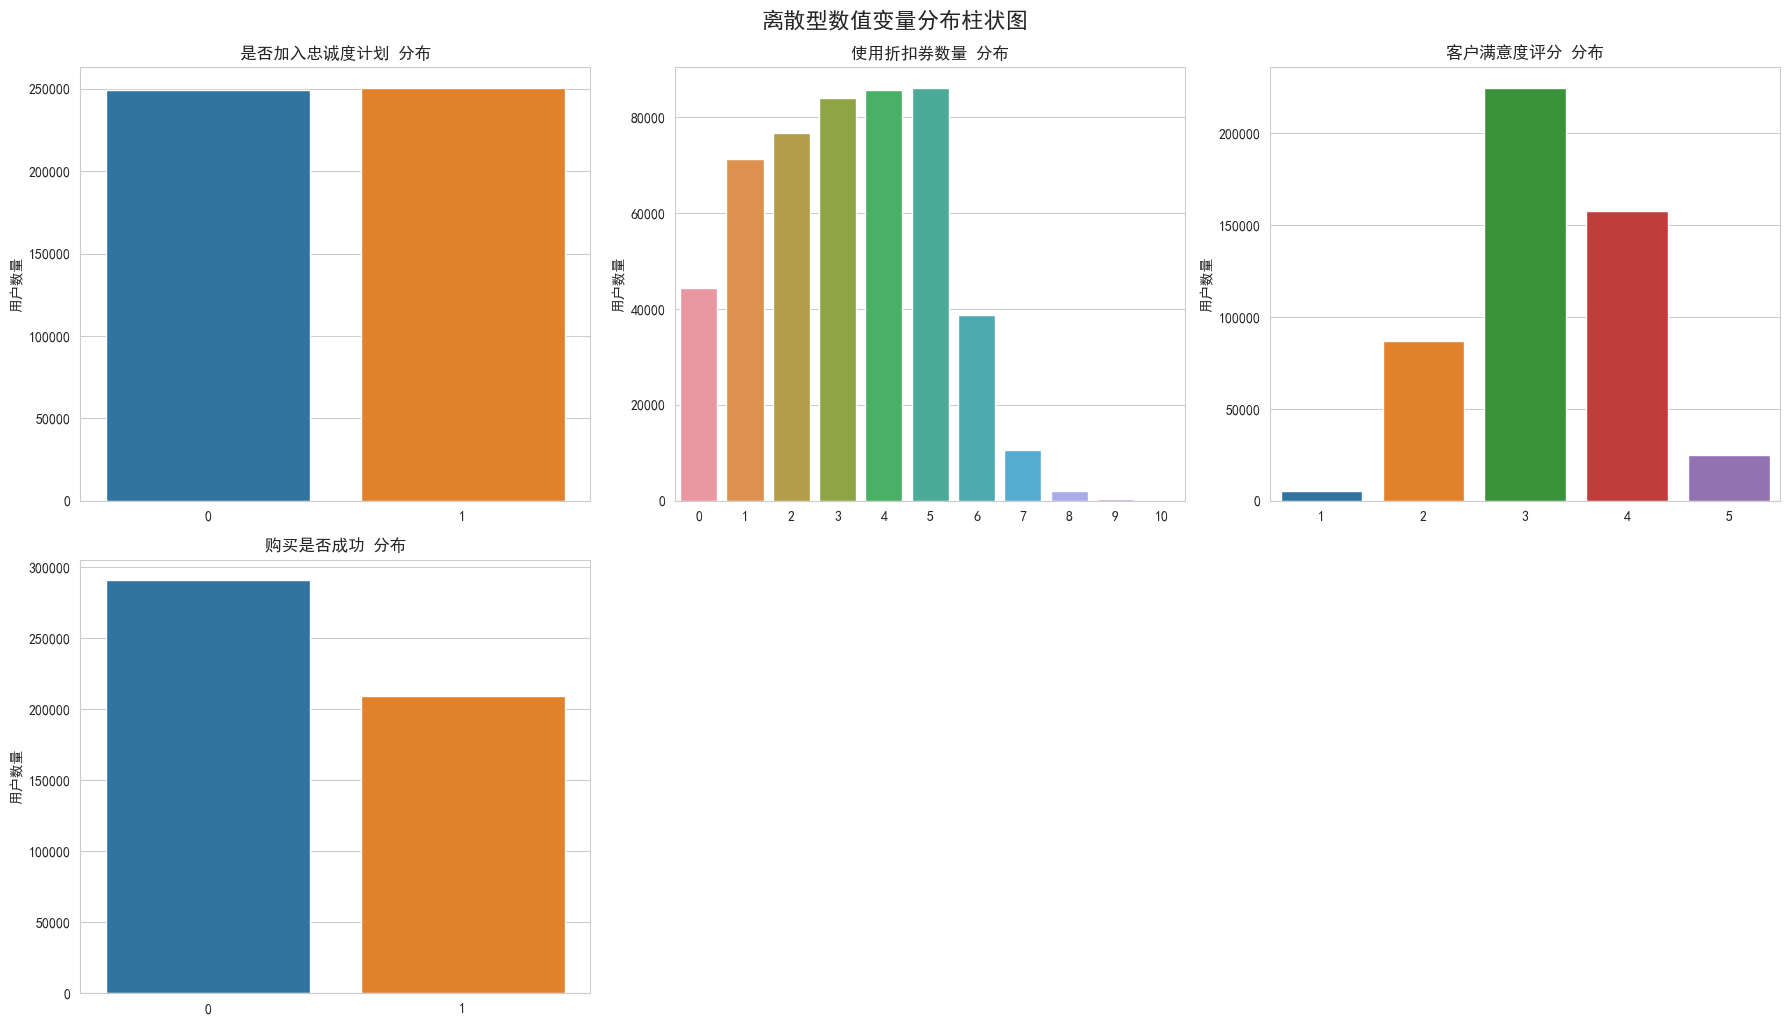

In [13]:
# 2. 离散型数值变量：计数柱状图 
n_disc = len(discrete_numeric_cols)
rows_disc = (n_disc + 2) // 3
fig, axs = plt.subplots(rows_disc, 3, figsize=(18, 5 * rows_disc))
axs = axs.flatten()

for i, col in enumerate(discrete_numeric_cols):
    sns.countplot(data=df, x=col, ax=axs[i])
    axs[i].set_title(f'{col} 分布', fontsize=12)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('用户数量')

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle('离散型数值变量分布柱状图', fontsize=16, y=1.02)
plt.show()

```
是否加入忠诚度计划：用户二分化，各占约50%；
使用折扣券数量：用户对折扣券依赖度较高
客户满意度评分：用户满意度以中等偏上为主，极端评价少
购买是否成功：购买转化整体偏低，仍有优化空间
```

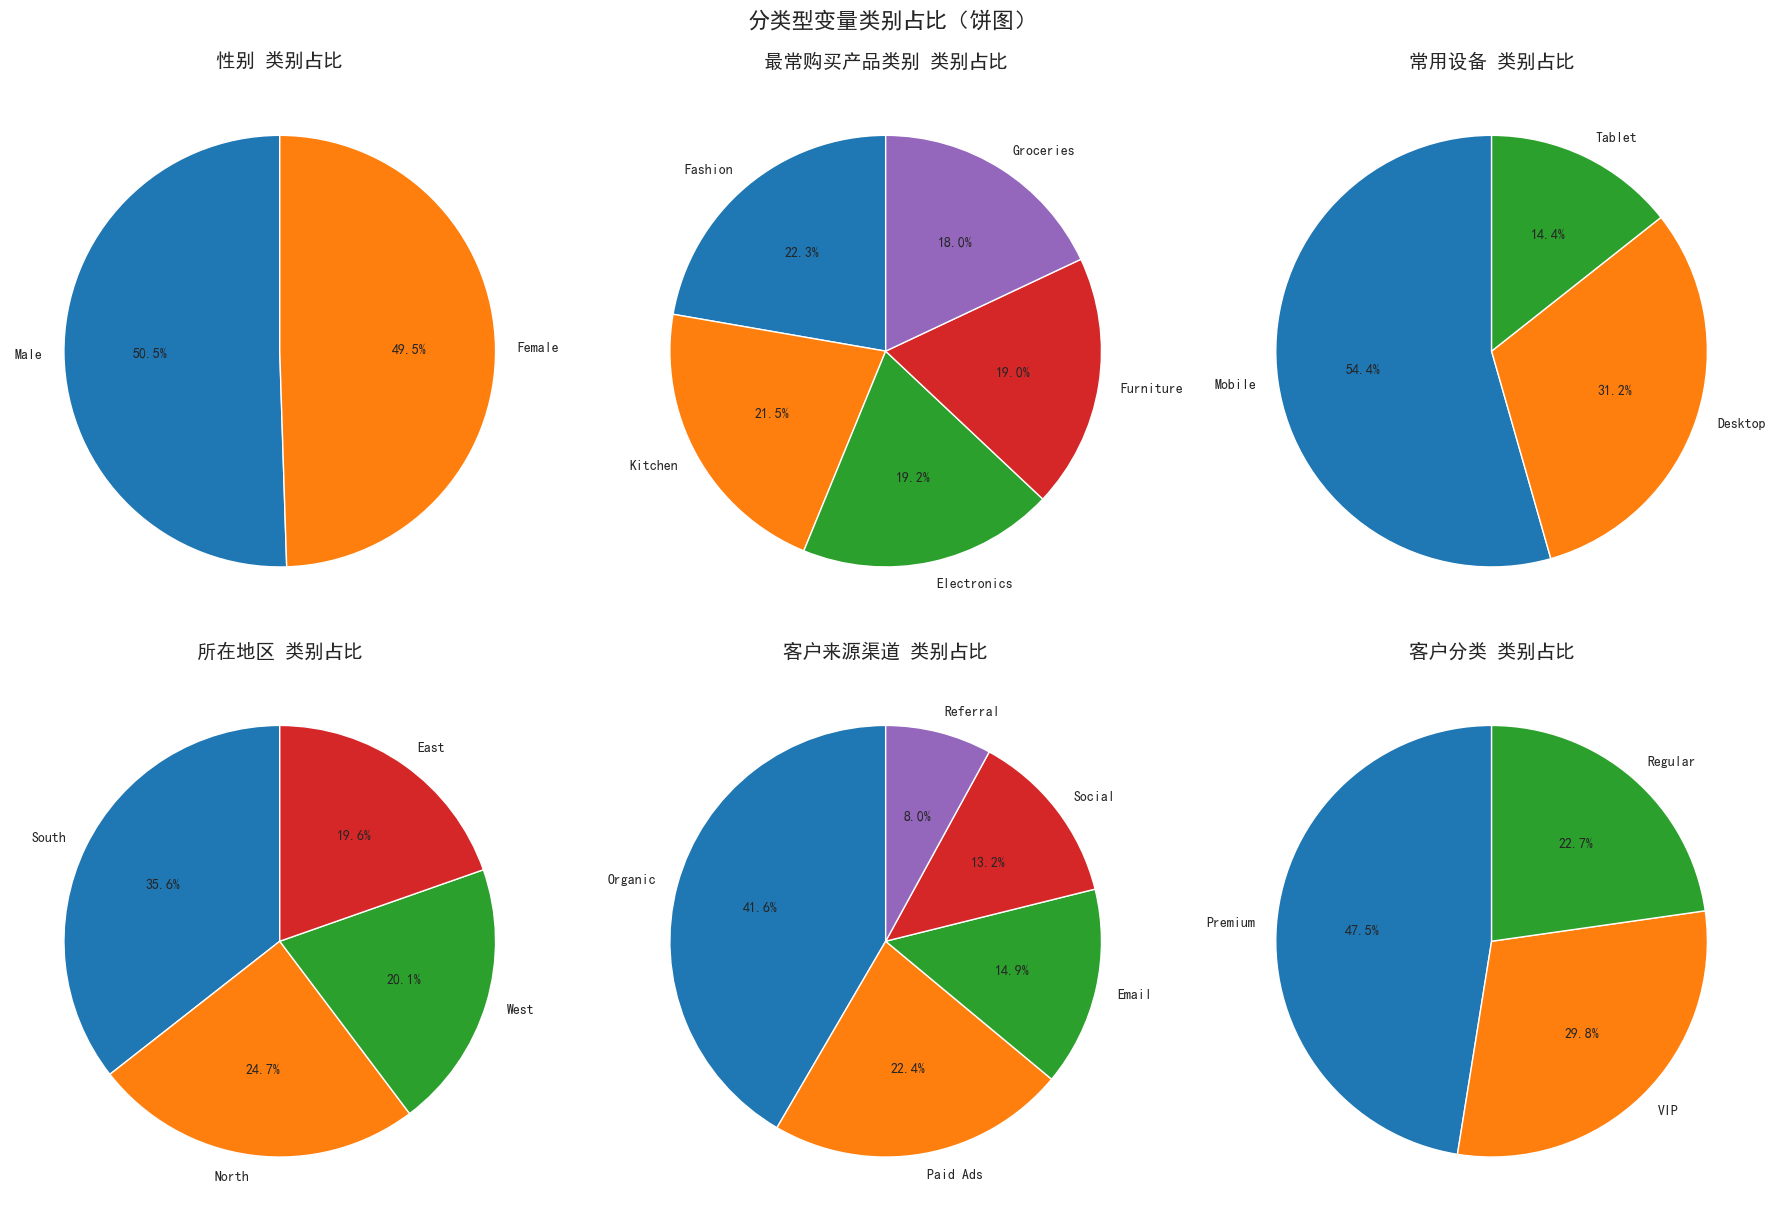

In [37]:
# 3. 分类型变量：饼图
n_cat = len(category_cols)
rows_cat = (n_cat + 2) // 3
fig, axs = plt.subplots(rows_cat, 3, figsize=(18, 6 * rows_cat))
axs = axs.flatten()

for i, col in enumerate(category_cols):
    # 统计各类别数量
    count = df[col].value_counts()
    # 饼图
    wedges, texts, autotexts = axs[i].pie(
        count, 
        labels=count.index, 
        autopct='%1.1f%%',  # 显示百分比
        startangle=90, 
        textprops={'fontsize': 10}
    )
    axs[i].set_title(f'{col} 类别占比', fontsize=14, pad=10)

# 删除多余子图
for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle('分类型变量类别占比（饼图）', fontsize=16, y=1.02)
plt.show()

```
性别：男女分布较平均；
最常购买产品类别：总体差距较小，Fashion类产品购买人数最多；
常用设备：使用移动设备的人数最多，可以优先提高移动端体验；
所在地区：南方地区人数最多，北方地区次之，其他地区分布差距较小；
客户来源渠道：主要来源为Organic（自然流量），其他来源相对较少，可以加大在其他渠道的宣传力度
客户分类：Premium（高级用户）最多，VIP次之，普通用户最少，高价值用户占比突出
```

#### 相关性分析

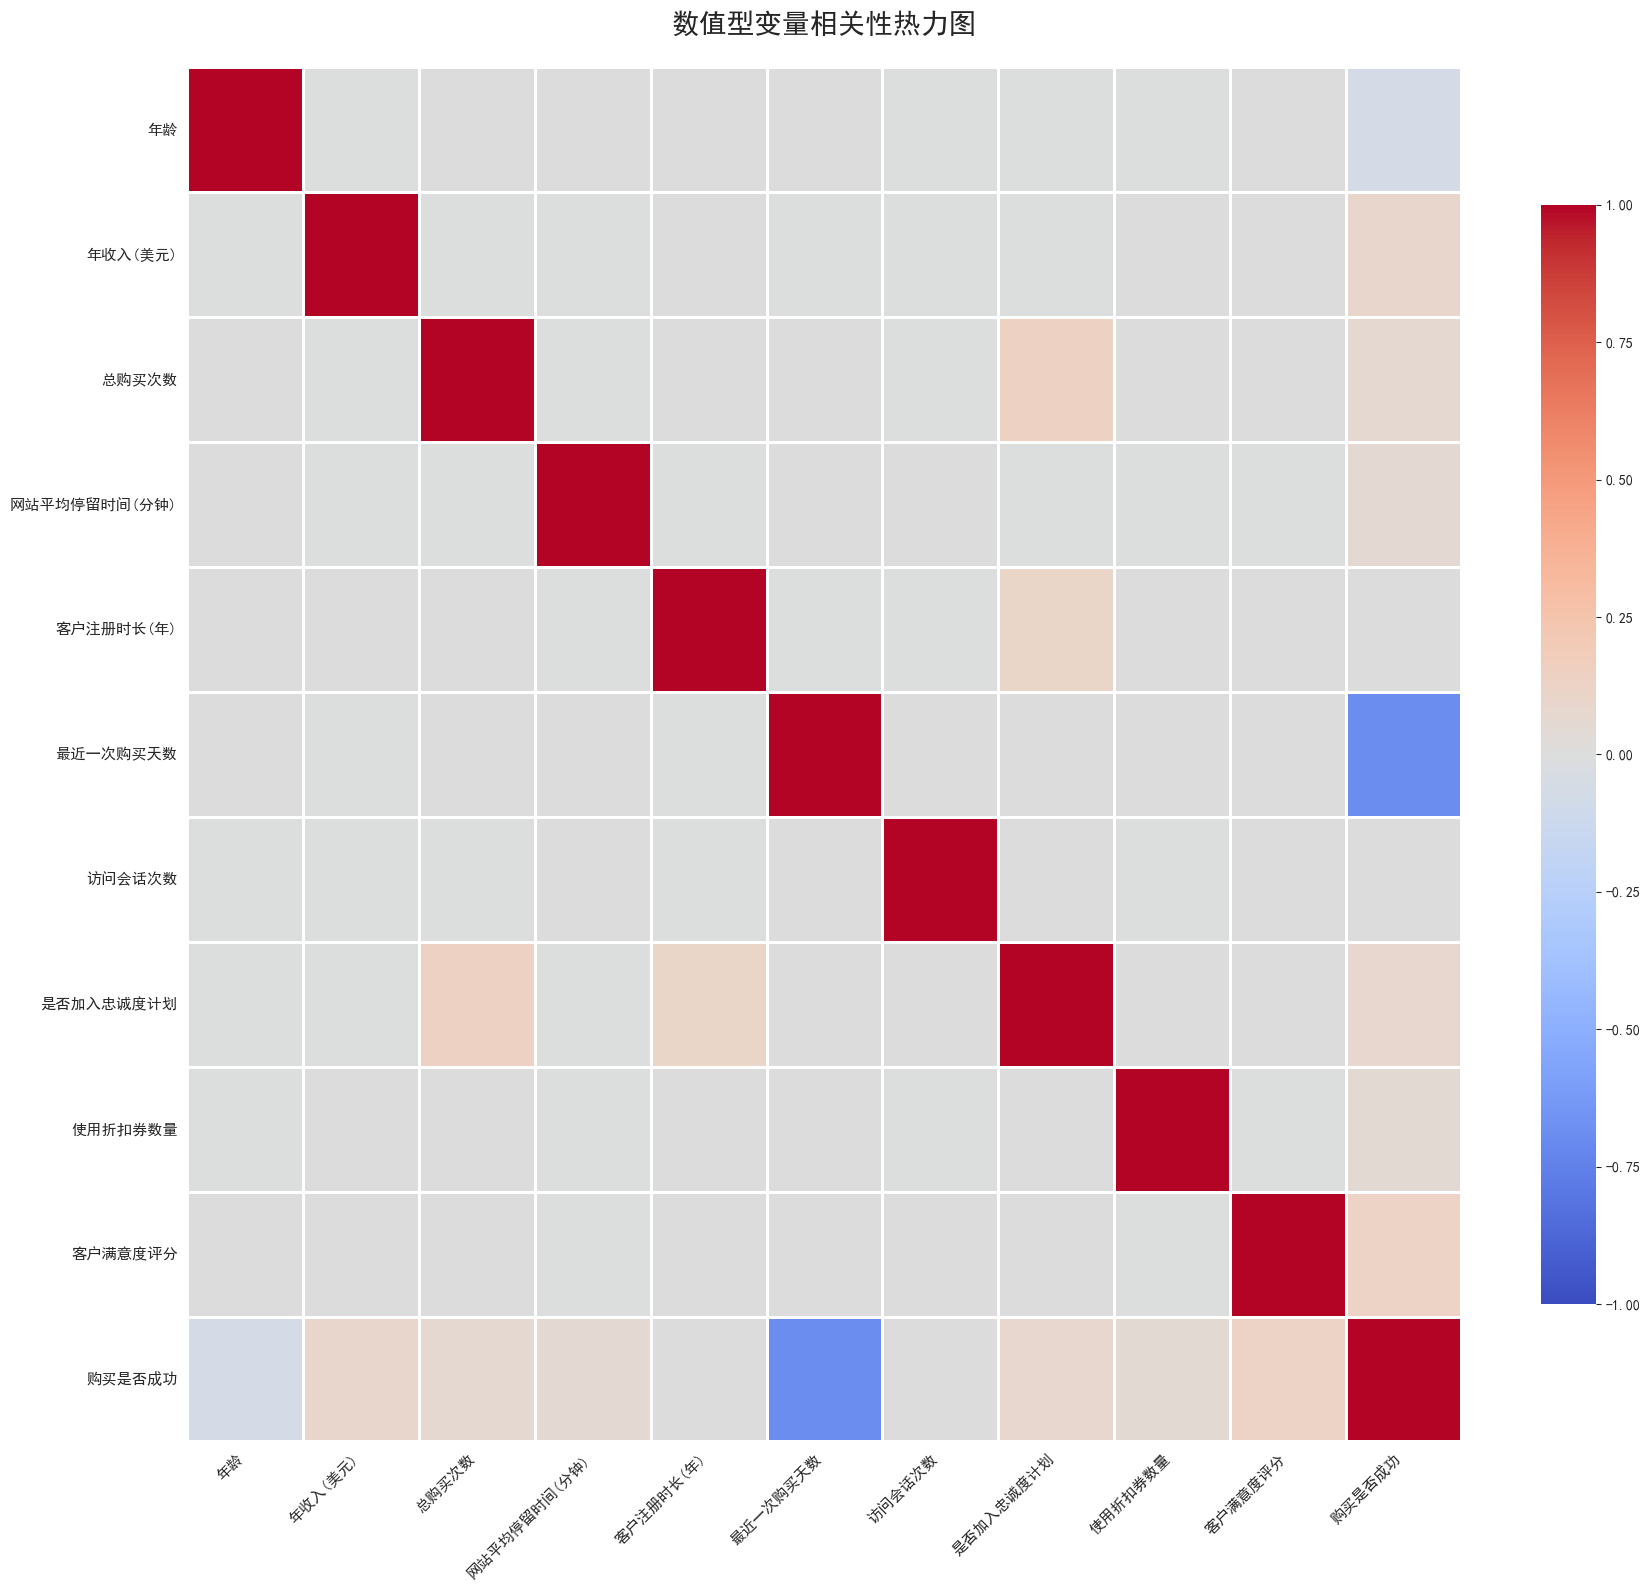

In [15]:
# 数值变量相关性热力图
corr_num = df[numeric_cols].corr()

plt.figure(figsize=(18, 16))
sns.heatmap(
    corr_num,
    annot=False,       
    cmap='coolwarm',
    linewidths=1,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.title('数值型变量相关性热力图', fontsize=20, pad=25)
plt.tight_layout()
plt.show()

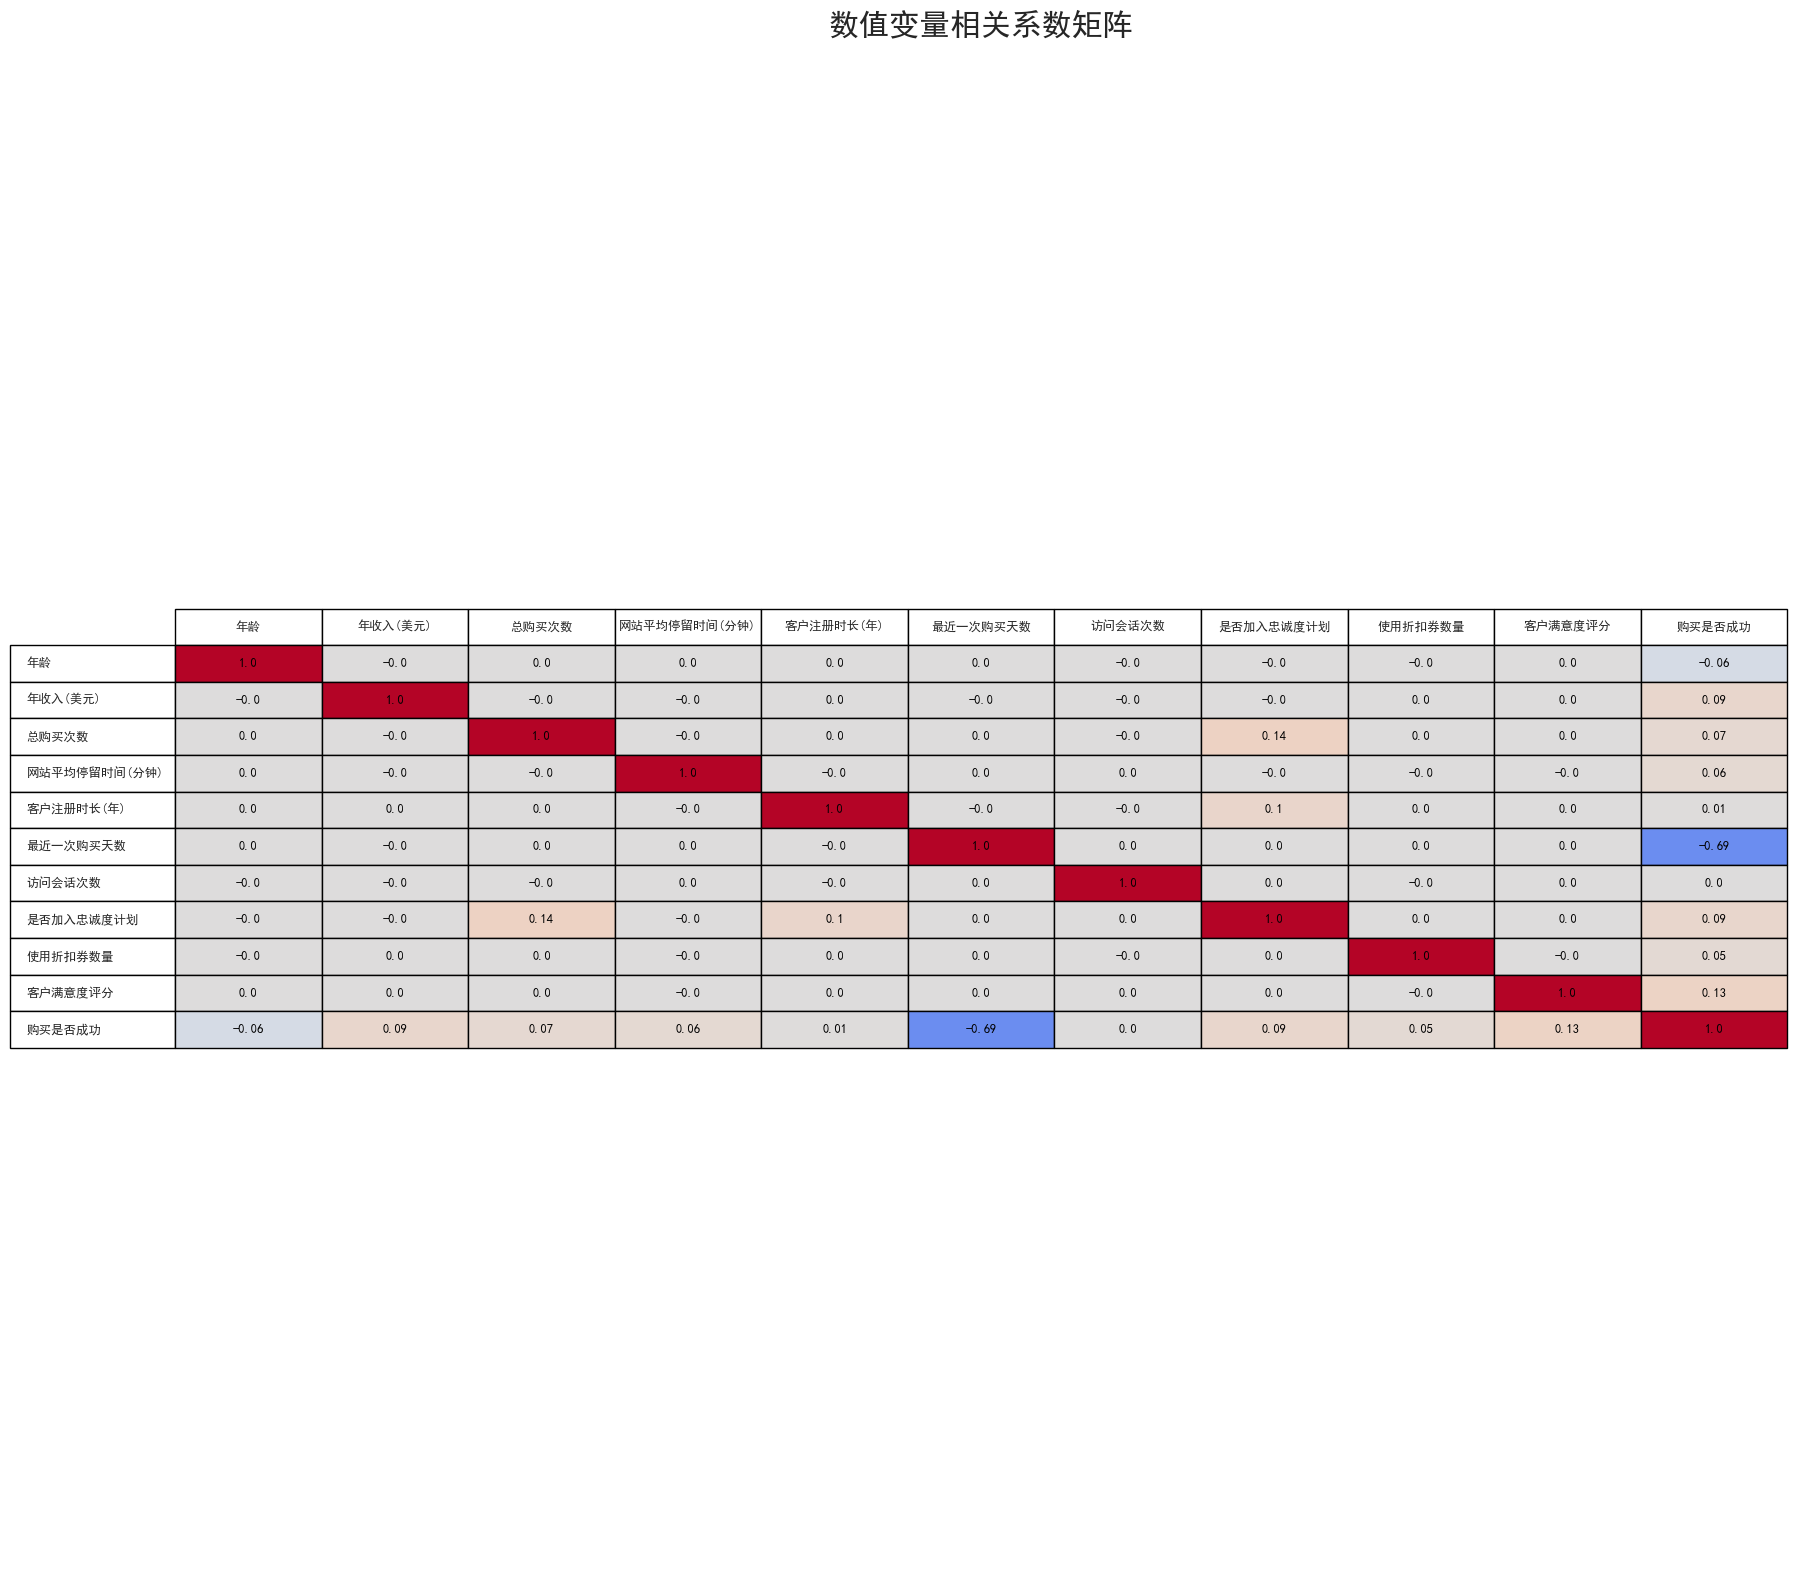

In [16]:
corr_table = corr_num.round(2)
fig, ax = plt.subplots(figsize=(18, 16))
ax.axis('tight')
ax.axis('off')

# 把相关系数转成 numpy 数组 方便遍历
values = corr_table.values

# 定义颜色映射（蓝色 → 白 → 红）
cmap = plt.get_cmap('coolwarm')

colors = cmap((values + 1) / 2)

# 创建表格
table = ax.table(
    cellText=values,
    colLabels=corr_table.columns,
    rowLabels=corr_table.index,
    cellLoc='center',
    loc='center',
    colWidths=[0.08] * len(corr_table.columns)
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)  

for i in range(len(corr_table)):
    for j in range(len(corr_table.columns)):
        cell = table[(i+1, j)]  
        cell.set_facecolor(colors[i][j])
        cell.set_text_props(weight='bold', color='black')

plt.title('数值变量相关系数矩阵', fontsize=22, pad=30)
plt.tight_layout()
plt.show()

```
1. 核心转化驱动因素
最近一次购买天数是影响购买成功率的唯一强相关因素，说明用户活跃度是转化的核心，沉睡用户（久未购买）是转化瓶颈。
建议：针对久未购买的用户做精准召回营销，用专属优惠券、个性化推荐唤醒。
客户满意度与购买成功率呈弱正相关，说明提升用户体验能小幅促进转化。
建议：针对低分用户做售后调研，优化服务流程，提升整体满意度。
2. 用户分层与会员运营
总购买次数、客户注册时长与会员加入呈弱正相关，说明老用户、高购买频次用户更愿意加入会员，会员权益有效提升用户粘性。
建议：针对新用户推出首单会员优惠，针对老用户升级会员权益，提升会员渗透率。
3. 基础属性的影响
年龄、收入等基础属性对购买行为几乎无影响，说明用户的消费决策更多由行为特征（活跃度、会员身份、满意度）驱动，而非人口属性。
建议：运营策略无需按年龄 / 收入分层，重点围绕用户行为做精准运营。
```

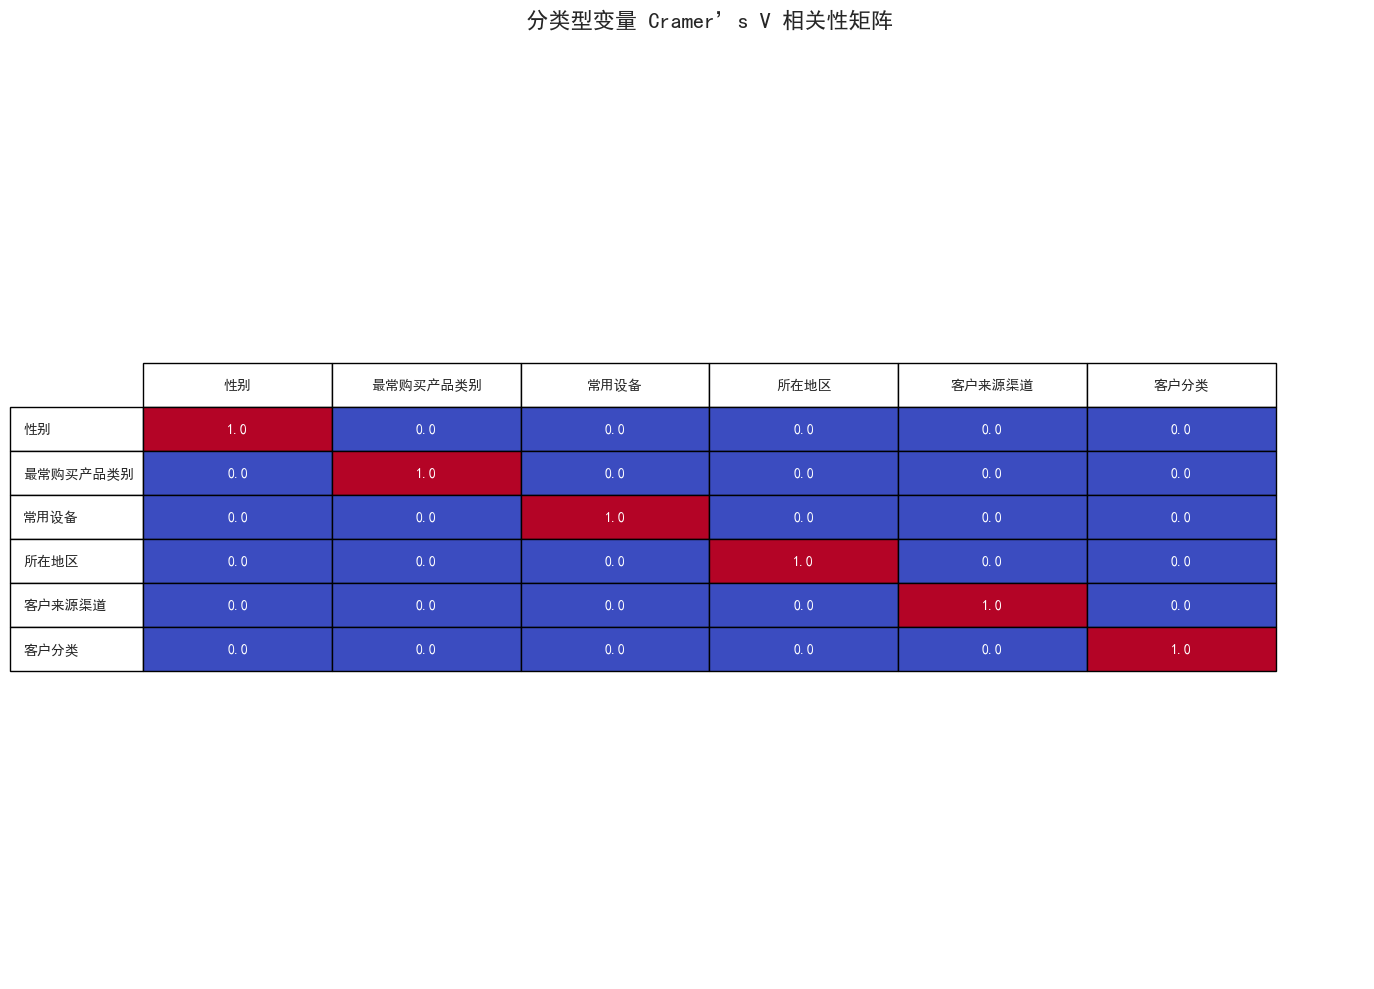

In [17]:
# 分类变量相关性热力图（Cramer's V）
# 计算Cramer's V函数
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(r-1, k-1))

# 构建相关矩阵
n = len(category_cols)
corr_cat = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        corr_cat[i, j] = cramers_v(df[category_cols[i]], df[category_cols[j]])

corr_cat_df = pd.DataFrame(corr_cat, index=category_cols, columns=category_cols)
corr_table_cat = corr_cat_df.round(2)  

# 生成彩色表格
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('tight')
ax.axis('off')

values_cat = corr_table_cat.values
cmap = plt.get_cmap('coolwarm')
colors_cat = cmap(values_cat)

# 创建表格
table = ax.table(
    cellText=values_cat,
    colLabels=corr_table_cat.columns,
    rowLabels=corr_table_cat.index,
    cellLoc='center',
    loc='center',
    colWidths=[0.12] * len(corr_table_cat.columns)
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.2)

# 给每个格子上色
for i in range(len(corr_table_cat)):
    for j in range(len(corr_table_cat.columns)):
        cell = table[(i+1, j)]
        cell.set_facecolor(colors_cat[i][j])
        cell.set_text_props(weight='bold', color='white', size=10)

plt.title('分类型变量 Cramer’s V 相关性矩阵', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

```
通过 Cramer's V 相关性分析发现，在6个核心分类变量（性别、产品偏好、设备、地区、渠道、客户分层）中，任意两个变量之间的相关系数均接近0。
这表明不同分类维度之间存在较强的独立性，即用户的来源渠道不决定其所在地区，产品偏好也不显著关联于性别。
说明我们在做用户分层时，各维度指标的覆盖度较为全面。
```

### 深入分析各因素与购买状态之间的关系

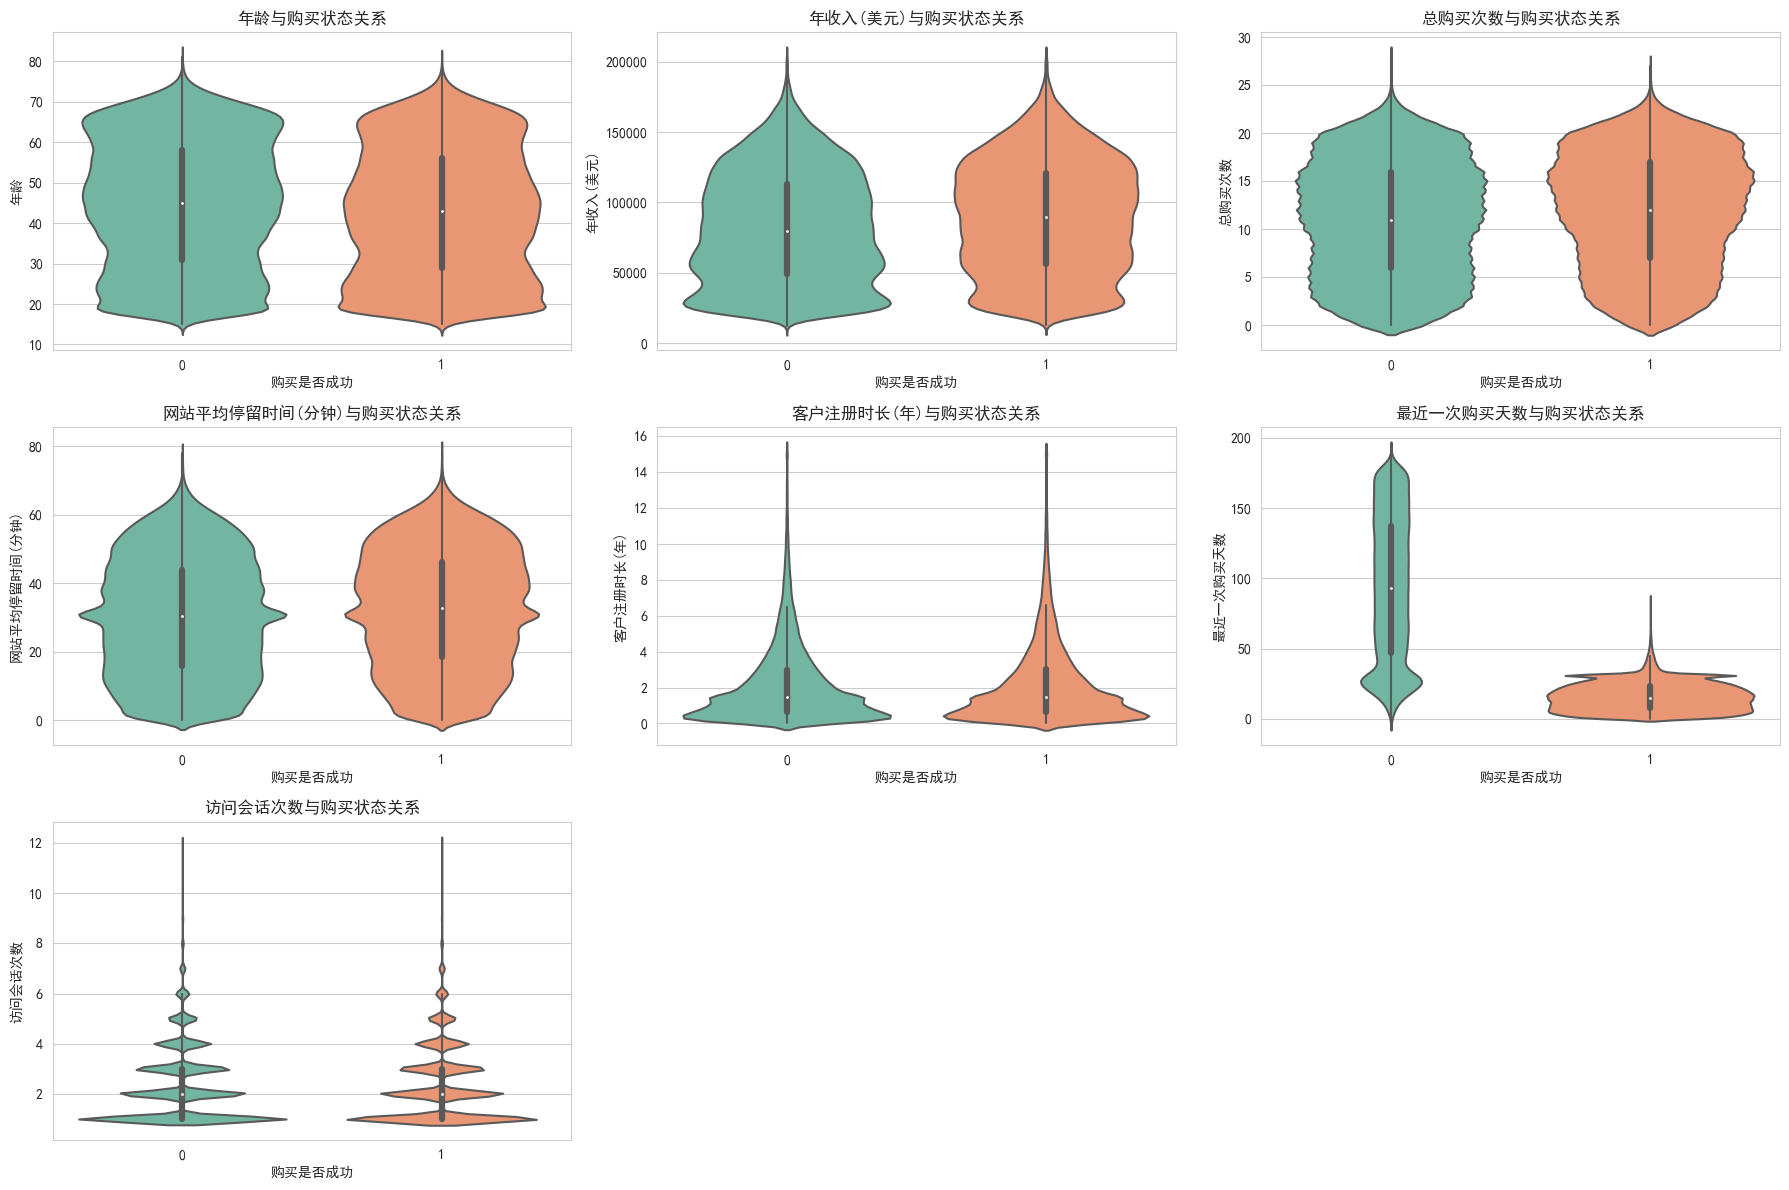

In [18]:
# 1. 连续变量与购买是否成功的小提琴图对比
plt.figure(figsize=(18,12))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3,3,i)
    sns.violinplot(x='购买是否成功', y=col, data=df, split=True, palette='Set2')
    plt.title(f'{col}与购买状态关系')
plt.tight_layout()
plt.show()

```
1. 年龄
30岁往下的用户购买转化率更高，60岁往上的用户购买转化率更低
结论：年龄对购买转化率有影响。
2. 年收入
购买成功用户的收入分布整体略高于未成功用户，中位数更高、高收入区间占比更大。
结论：收入水平与购买转化呈正相关，高收入用户更易完成购买。
3. 总购买次数
两类用户分布几乎完全一致，中位数均在10次左右，无明显差异。
结论：历史购买总次数无法有效区分购买转化能力。
4. 网站平均停留时间 
购买成功用户中高停留时长（>30分钟）占比更高，中位数略高于未成功用户。
结论：停留时间越长，购买转化概率越高，用户兴趣度是转化的重要驱动。
5. 客户注册时长 
两类用户分布高度相似，中位数均在2年左右，无显著差异。
结论：注册时长对购买转化无明显影响。
6. 最近一次购买天数
差异最显著的特征：
未成功用户：分布极分散，中位数接近100天，大量用户超过150天未购买。
成功用户：分布高度集中，中位数<30天，几乎无超过50天的用户。
结论：最近购买时间越近，购买转化概率越高，用户活跃度是转化的核心指标。
7. 访问会话次数
两类用户分布几乎完全重合，中位数均在2次左右，无明显差异。
结论：访问会话次数对购买转化无显著区分度。
```

```
业务优化建议
针对高活跃度用户：对最近30天内有购买记录、停留时间长的用户，推送复购优惠、个性化推荐，提升复购率。
针对高收入用户：针对高收入客群推出高端产品、专属权益，挖掘消费潜力。
针对沉睡用户：对超过90天未购买的用户，通过召回券、专属活动激活，降低流失率。
优化用户体验：通过内容运营、个性化推荐延长用户停留时间，提升转化概率。
```

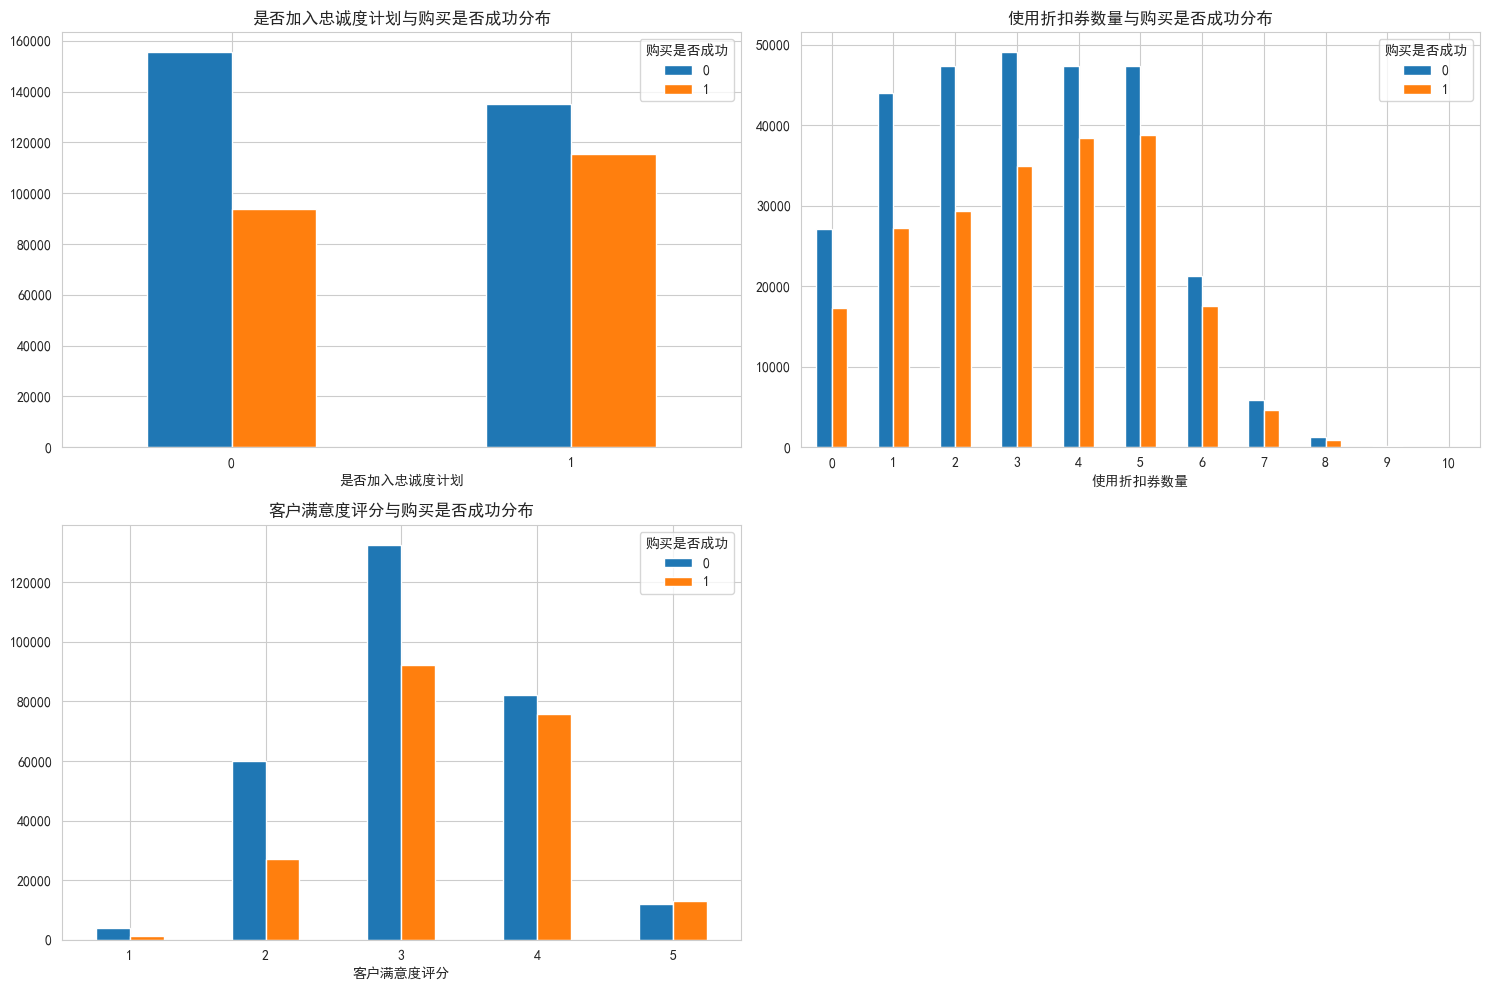

In [19]:
# 2. 离散数值变量与购买状态的分组柱状图
plt.figure(figsize=(15,10))
for i, col in enumerate(['是否加入忠诚度计划','使用折扣券数量','客户满意度评分'],1):
    plt.subplot(2,2,i)
    df.groupby([col,'购买是否成功']).size().unstack().plot(kind='bar',ax=plt.gca())
    plt.title(f'{col}与购买是否成功分布')
    plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

```
1. 是否加入忠诚度计划
加入忠诚度计划的用户，购买成功率显著更高；
忠诚度计划是提升购买转化的有效抓手，会员用户的消费意愿更强。
2. 使用折扣券数量
折扣券使用数量与购买成功率呈强正相关，使用券越多，购买转化概率越高；
3-5 张折扣券是撬动用户转化的最优区间，可针对性发放该档位的优惠。
3. 客户满意度评分
满意度评分与购买成功率呈正相关，满意度越高，购买转化概率越高；
3分是用户基数最大的档位，提升该档位用户的满意度，是整体转化提升的关键。
```

```
1.忠诚度计划运营：
针对非会员用户，推出入会专属优惠，引导用户加入会员，提升转化；
针对会员用户，推出专属权益、积分体系，提升复购率与用户粘性。
2.折扣券策略优化：
针对 0-2 张券的低转化用户，发放 3-5 张档位的优惠券，撬动转化；
针对高券数用户，推出满减、组合优惠，提升客单价与复购。
3.满意度提升运营：
针对 1-2 分的低满意度用户，进行售后回访、问题解决，挽回流失；
针对 3 分的中等满意度用户，通过服务优化、个性化推荐，提升满意度至 4-5 分，放大转化潜力；
针对 5 分的高满意度用户，打造口碑传播，通过老带新拉新转化。
```

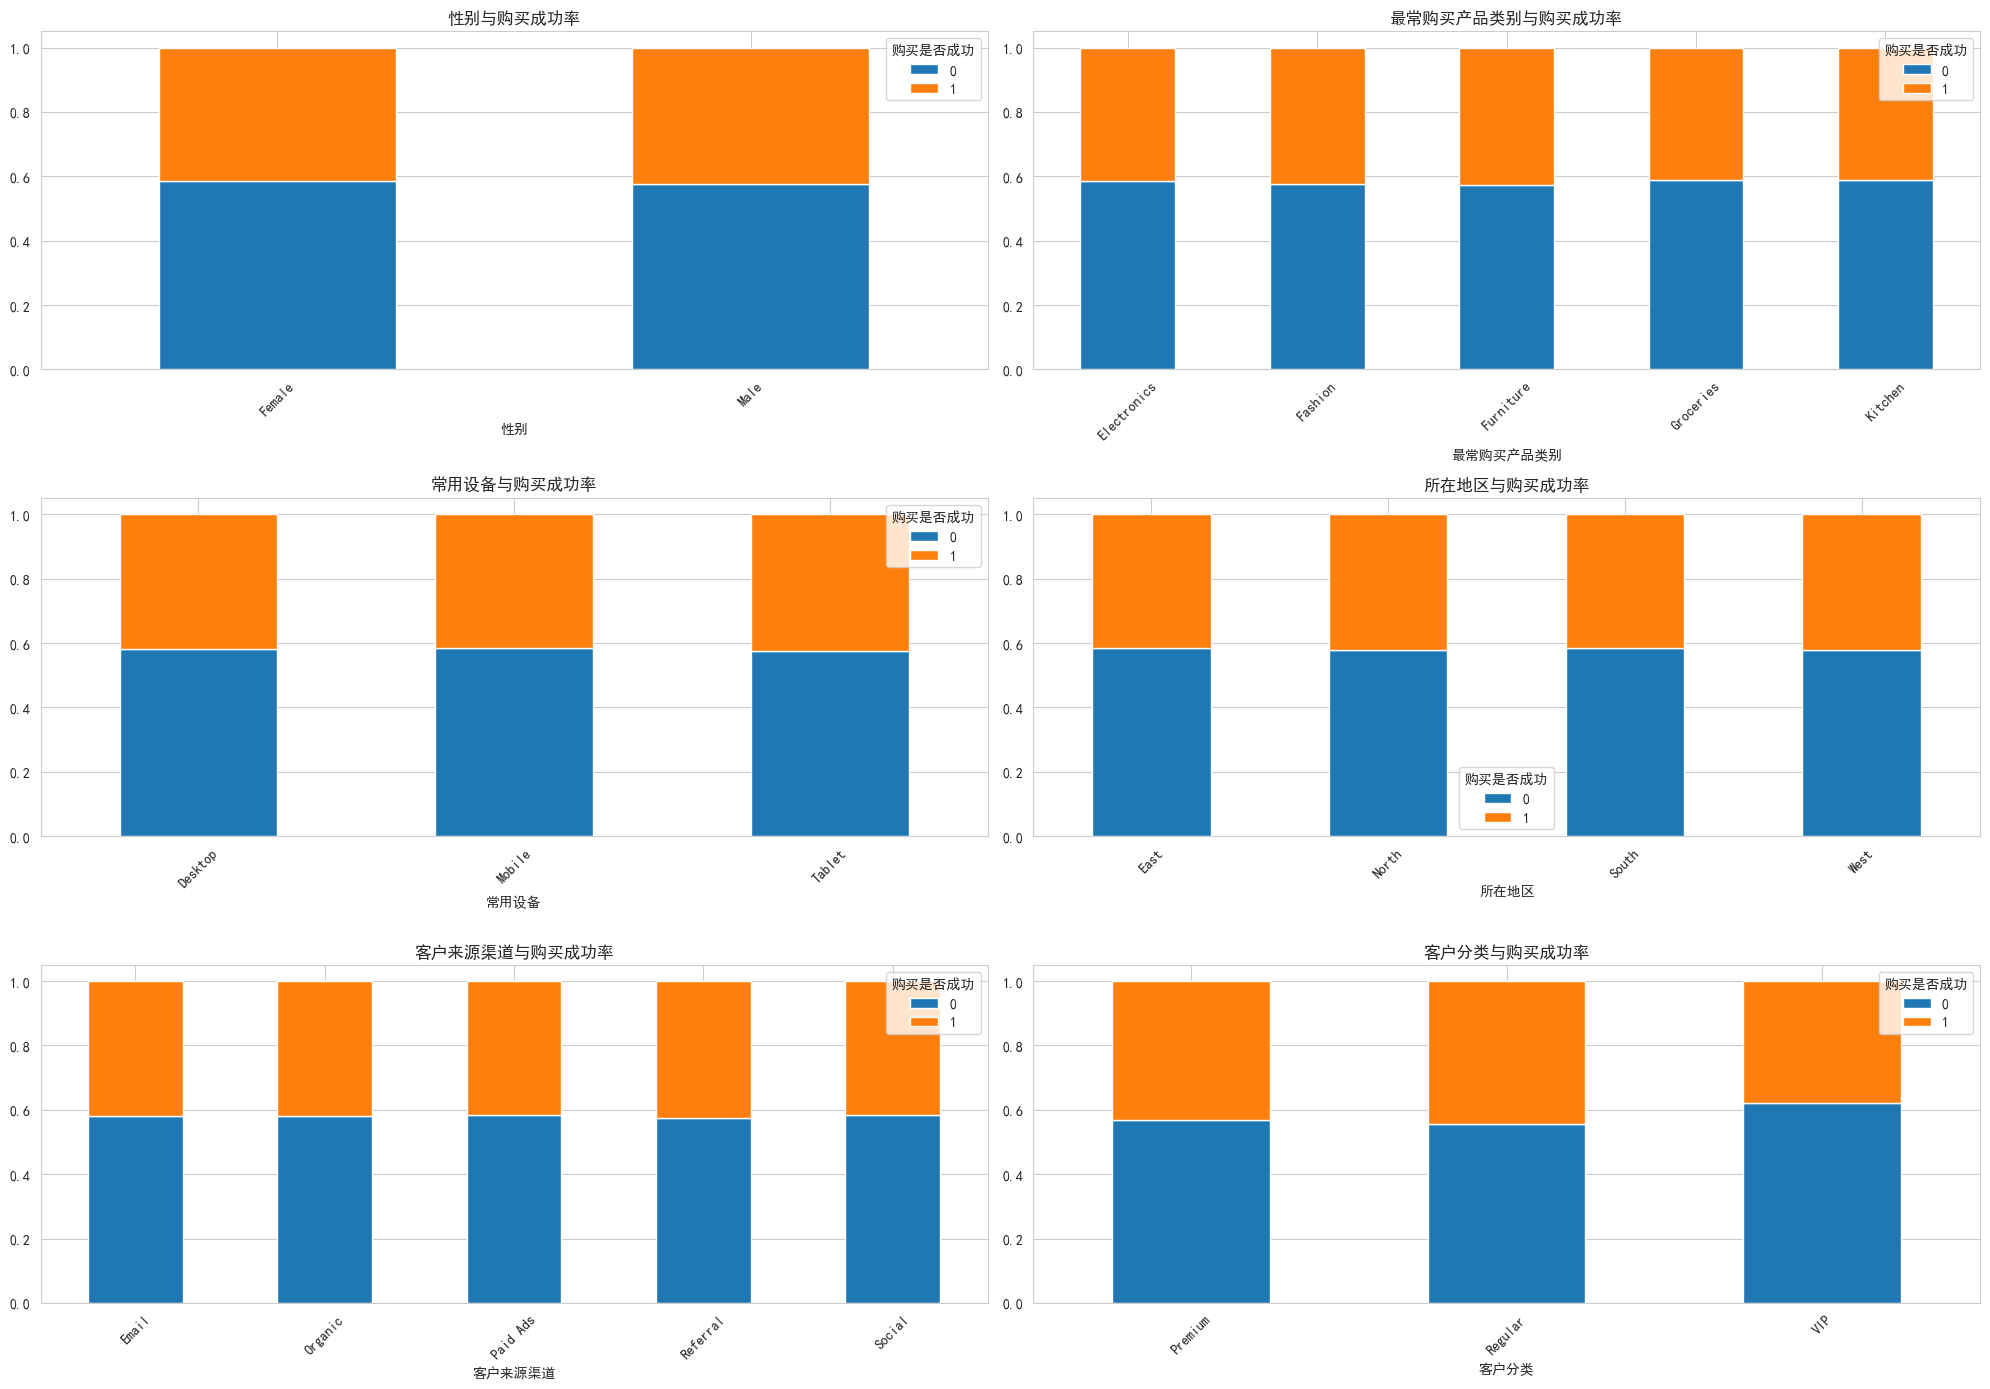

In [20]:
# 3. 分类变量与购买状态的堆叠柱状图
plt.figure(figsize=(20,14))
for i, col in enumerate(category_cols,1):
    plt.subplot(3,2,i)
    pd.crosstab(df[col],df['购买是否成功'],normalize='index').plot(kind='bar',stacked=True,ax=plt.gca())
    plt.title(f'{col}与购买成功率')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

```
客户分类是强影响特征，但转化逻辑与直觉相反:VIP用户的购买转化率要小于其他用户；
其他因素对购买转化率影响较小；
VIP用户是当前转化的短板，需要针对性优化运营策略；
其他用户是转化的核心基本盘，需稳定其转化效率。
```

```
1.VIP用户运营优化
重新定位VIP 权益：将高门槛权益调整为“高频、实用”的专属福利（如专属折扣、优先发货、免费试用），匹配VIP用户的实际购买需求；
激活沉睡VIP：针对长期未购买的VIP用户，发放专属召回券、个性化推荐，唤醒购买意愿；
优化VIP准入标准：将VIP标准，调整为“消费金额 + 活跃度”双维度，避免大量沉睡用户占用 VIP 名额。
2.普通用户运营优化
稳定转化基本盘：保持日常优惠、个性化推荐的力度，维持普通用户的高转化效率；
引导升级：针对高转化的普通用户，推出VIP升级专属福利，引导其升级为VIP，提升用户生命周期价值。
```

### 用户画像分析

#### 特征选择

In [23]:
# 仅保留对购买转化有显著影响的特征
numeric_cluster_features = [
    '年龄', '年收入(美元)', '网站平均停留时间(分钟)', '最近一次购买天数',
    '是否加入忠诚度计划', '使用折扣券数量', '客户满意度评分'
]
categorical_cluster_features = ['客户分类']  

# 特征预处理
preprocessor = ColumnTransformer(
    transformers=[
        # 数值特征标准化（消除量纲影响）
        ('num', StandardScaler(), numeric_cluster_features),
        # 分类特征独热编码（drop='first'避免多重共线性）
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cluster_features)
    ],
    remainder='drop'  # 丢弃未使用的特征
)

# 执行预处理
X = df[numeric_cluster_features + categorical_cluster_features].copy()
X_scaled = preprocessor.fit_transform(X)

#### 确定最佳聚类数（K值）

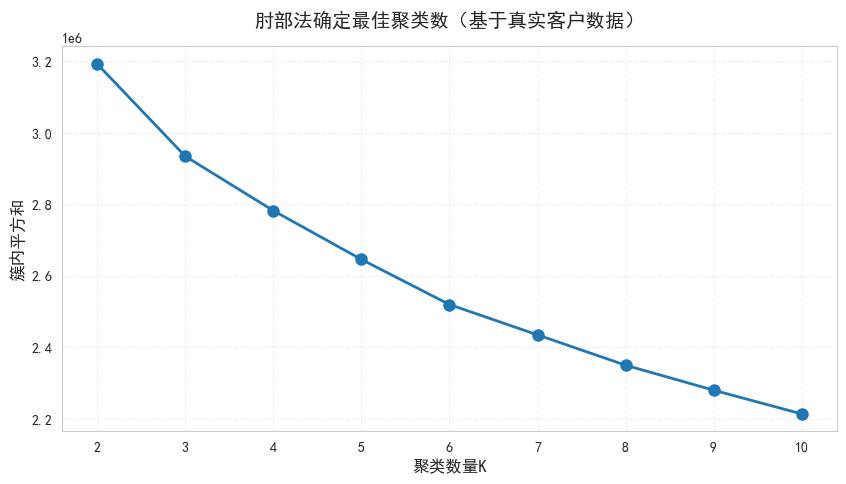

In [25]:
# 肘部法确定最佳K值
inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 可视化肘部法结果
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8, color='#1f77b4')
plt.xlabel('聚类数量K', fontsize=12)
plt.ylabel('簇内平方和', fontsize=12)
plt.title('肘部法确定最佳聚类数', fontsize=14, pad=15)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#### 执行K-Means聚类

In [26]:
best_k = 3 
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
df['用户簇'] = kmeans_model.fit_predict(X_scaled)

In [28]:
# 聚类结果深度分析
# 数值特征均值
cluster_numeric = df.groupby('用户簇')[numeric_cluster_features].mean().round(2)
# 客户分类占比
cluster_category = pd.crosstab(df['用户簇'], df['客户分类'], normalize='index').round(2) * 100
# 购买成功率
cluster_conv = df.groupby('用户簇')['购买是否成功'].mean().round(2) * 100
# 样本量与占比
cluster_size = df['用户簇'].value_counts().sort_index()
cluster_size_pct = (cluster_size / cluster_size.sum()).round(2) * 100

# 合并分析结果
cluster_analysis = pd.concat([
    cluster_numeric,
    cluster_category.add_suffix('占比(%)'),
    cluster_conv.rename('购买成功率(%)'),
    cluster_size.rename('样本量'),
    cluster_size_pct.rename('样本占比(%)')
], axis=1)

print("基于K=3的用户簇分析结果")
print(cluster_analysis)

基于K=3的用户簇分析结果
        年龄   年收入(美元)  网站平均停留时间(分钟)  最近一次购买天数  是否加入忠诚度计划  使用折扣券数量  客户满意度评分  \
用户簇                                                                         
0    43.95  85151.80         31.20     31.52        0.0     3.15     3.22   
1    43.95  84961.21         31.11    140.34        0.5     3.16     3.22   
2    43.93  85072.97         31.07     31.50        1.0     3.15     3.22   

     Premium占比(%)  Regular占比(%)  VIP占比(%)  购买成功率(%)     样本量  样本占比(%)  
用户簇                                                                   
0            47.0          23.0      30.0      51.0  182856     37.0  
1            47.0          23.0      30.0       0.0  134189     27.0  
2            48.0          23.0      30.0      63.0  182955     37.0  



#### 聚类结果可视化（PCA降维）

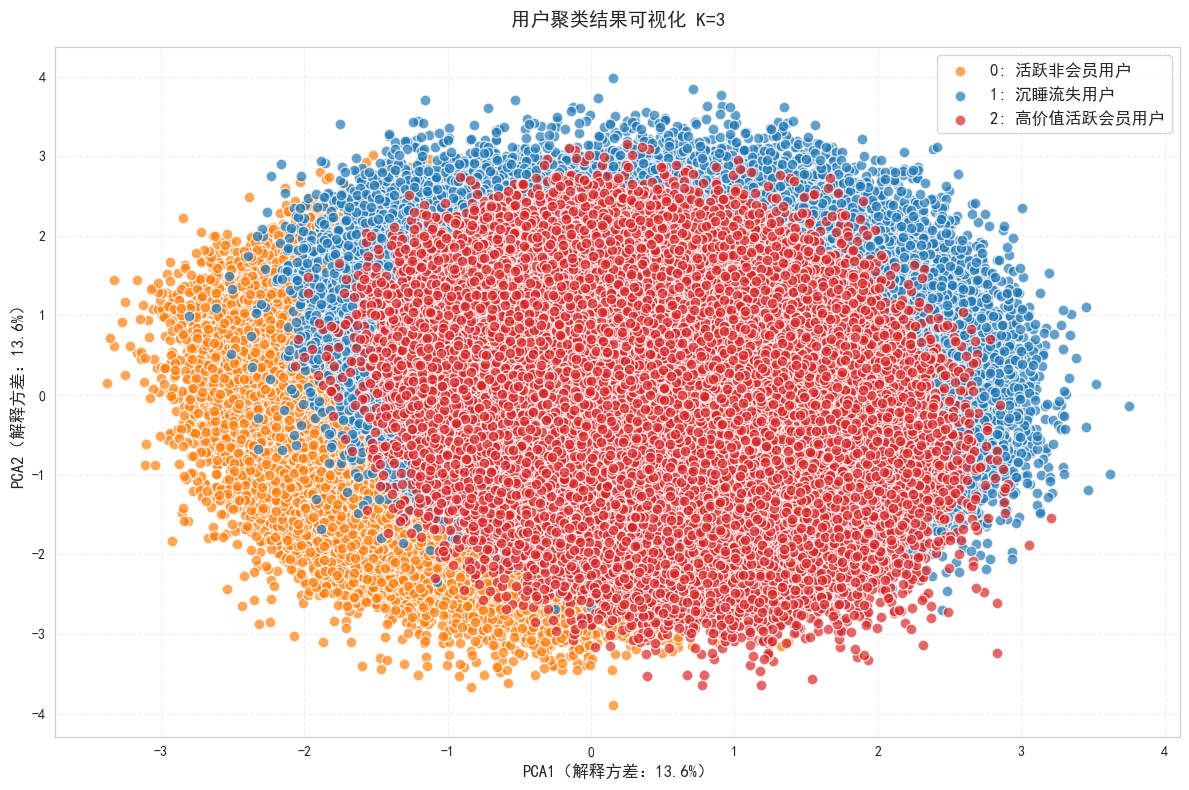

In [35]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))

colors = ['#ff7f0e', '#1f77b4', '#d62728']
cluster_labels = [
    '0: 活跃非会员用户',
    '1: 沉睡流失用户',
    '2: 高价值活跃会员用户'
]

for i in range(best_k):
    mask = df['用户簇'] == i
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[i], label=cluster_labels[i],
        alpha=0.7, s=60, edgecolors='white'
    )

plt.legend(fontsize=12)
plt.title(f'用户聚类结果可视化 K={best_k}', fontsize=14, pad=15)
plt.xlabel(f'PCA1（解释方差：{pca.explained_variance_ratio_[0]:.1%}）', fontsize=12)
plt.ylabel(f'PCA2（解释方差：{pca.explained_variance_ratio_[1]:.1%}）', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

```
图中展示了基于 K=3 的用户聚类结果，通过 PCA 将高维特征降维到二维空间。
横轴 PCA1（解释方差 13.6%）主要反映用户活跃度与会员身份，纵轴 PCA2（解释方差 13.6%）反映网站参与度。
三个簇边界清晰、分离度良好：橙色代表活跃非会员用户，蓝色代表沉睡流失用户，红色代表高价值活跃会员用户。
聚类结果在空间上呈现明显梯度，对应真实数据中购买成功率的差异，说明聚类分群效果优秀、结构稳定。
```

#### 形成最终用户画像标签

In [36]:
user_labels = {
    0: "活跃非会员用户：非会员、近30天购买、购买成功率51%，高转化潜力",
    1: "沉睡流失用户：140天未购买、购买成功率0%，高流失风险",
    2: "高价值活跃会员用户：100%会员、近30天购买、购买成功率63%，核心价值用户"
}

df['用户画像标签'] = df['用户簇'].map(user_labels)

print("最终用户画像标签")

for cluster_id, label in user_labels.items():
    size = cluster_size[cluster_id]
    size_pct = cluster_size_pct[cluster_id]
    conv = cluster_conv[cluster_id]
    print(f"簇{cluster_id}（样本量：{size}，占比：{size_pct}%，购买成功率：{conv}%）：{label}")

最终用户画像标签
簇0（样本量：182856，占比：37.0%，购买成功率：51.0%）：活跃非会员用户：非会员、近30天购买、购买成功率51%，高转化潜力
簇1（样本量：134189，占比：27.0%，购买成功率：0.0%）：沉睡流失用户：140天未购买、购买成功率0%，高流失风险
簇2（样本量：182955，占比：37.0%，购买成功率：63.0%）：高价值活跃会员用户：100%会员、近30天购买、购买成功率63%，核心价值用户


### 结论与建议

```
（一）研究结论
1.用户整体特征
本次分析用户以中老年、中低收入群体为主，新用户占比极高，老用户留存随时间下降明显；
用户整体复购情况健康，对折扣券依赖度较高，满意度以中等偏上为主；
消费偏好集中于Fashion品类，主要使用移动设备购物，客户来源以自然流量为主，客户分层中 Premium 高级用户占比最高，高价值用户结构突出。
2.核心转化规律
用户活跃度是购买转化的第一核心因素，最近一次购买天数与购买成功率呈极强相关，活跃用户集中在近30天内购买，而大量沉睡用户是转化提升的主要瓶颈。
网站停留时间越长，转化概率越高，网站内容吸引力对转化有明显促进作用。
忠诚度计划可显著提升购买成功率，会员用户消费意愿更强；
折扣券使用数量与转化率呈强正相关，3–5张为最优转化区间。
年龄、收入对转化存在一定影响：30岁以下用户转化率更高，60岁以上偏低；高收入用户转化表现略好。
总购买次数、注册时长、访问会话次数对购买转化无显著区分度。
3.关键问题发现
VIP 用户转化率显著低于其他用户，成为当前转化短板，与业务直觉相反。
性别、产品类别、设备、地区、渠道、客户分层等分类维度相互独立，无明显交叉影响，用户分层体系较为全面。
4.用户聚类分群结论（K=3）
簇 0 活跃非会员用户（占比37%，转化率51%）：近期活跃、非会员，是会员转化的高潜力人群。
簇 1 沉睡流失用户（占比27%，转化率0%）：近140天未购买，为高流失风险群体。
簇 2 高价值活跃会员用户（占比37%，转化率63%）：100%会员、近期活跃，是平台营收核心支柱。
（二）业务优化建议
1. 聚焦活跃度，破解沉睡用户转化瓶颈
建立30/60/90天沉睡用户召回机制，对超过90天未购用户投放专属大额召回券与个性化推荐，快速激活沉默流量。
针对近30天活跃用户推送复购优惠、关联推荐，巩固高活跃度带来的高转化优势。
2. 强化会员体系，提升整体转化效率
面向活跃非会员用户推出入会立减、首月免费等政策，快速提升会员渗透率。
优化会员积分、专属价、优先发货等高频实用权益，增强会员粘性与复购率。
3. 精准优化折扣券与满意度运营
对低转化用户集中发放3–5张档位优惠券，提高转化概率；对高券数用户搭配满减与套餐，提升客单价。
重点提升3分中等满意度用户至4–5分，对1–2分低分用户开展售后回访与问题整改，降低流失风险。
4. 专项整改VIP用户短板
重构VIP权益，放弃高门槛福利，改为高频、即时、实用的专属优惠与服务。
对长期未购VIP启动专属唤醒活动，优化VIP准入规则，采用"消费金额+活跃度"双维度评定，避免沉睡用户占用名额。
5. 产品、渠道与体验升级
重点运营Fashion优势品类，优先优化移动端购物体验。
加大社交、推荐、付费等非自然流量渠道投放，降低流量结构风险。
通过内容运营与个性化推荐延长用户停留时间，释放高停留用户的转化潜力。
6. 运营策略聚焦行为特征
运营重心围绕活跃度、会员身份、优惠使用、满意度等行为特征展开，弱化年龄、收入等人口属性分层，提升运营精准度与效率。
```